## 🩺 Breast Cancer Classification using Artificial Neural Network (ANN)

This project builds an Artificial Neural Network (ANN) to classify breast tumors as **Benign** or **Malignant** using the Breast Cancer Wisconsin dataset from Scikit-learn.

**Dataset:** Breast Cancer Wisconsin Diagnostic Dataset  
**Framework:** TensorFlow / Keras  
**Language:** Python

**Task:** Binary Classification

 ## 📚 Importing the Required Libraries

Import all the necessary libraries required for data manipulation, visualization, preprocessing, model building, and evaluation.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# Set random seed for reproducibility
tf.random.set_seed(3)
import sklearn.datasets
from sklearn.model_selection import train_test_split

##  🔍 Exploring the Dataset

Explore the dataset to understand its features, target labels, and overall structure.

In [3]:
# loading the data from sklearn
breast_cancer_dataset = sklearn.datasets.load_breast_cancer()

In [4]:
print(breast_cancer_dataset)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]]), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
 

## 🏗 Creating a DataFrame

Convert the dataset into a Pandas DataFrame for easier analysis and manipulation.

In [5]:
# Loading the data to a data frame
data_frame = pd.DataFrame(breast_cancer_dataset.data, columns = breast_cancer_dataset.feature_names)

In [6]:
# Print the first 5 rows of the dataframe
data_frame.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 🏷 Adding the Target Labels

Append the target column (label) to the DataFrame.

In [7]:
# Adding the 'target column to the data frame
data_frame['label'] = breast_cancer_dataset.target

In [8]:
# Print last 5 rows of the dataframe
data_frame.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1


## 📊 Dataset Information

Check the dataset dimensions, data types, and missing values.

In [9]:
# Number of rows and columns in the dataset
data_frame.shape

(569, 31)

In [10]:
# Getting some information about the data
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [11]:
# Checking for missing Values
data_frame.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [12]:
# Statistical measures about the data
data_frame.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [13]:
# Checking the distribution of Target Variable
data_frame['label'].value_counts()

,count
label,
1,357
0,212


1 --> Benign ,

0 --> Malignant

In [14]:
data_frame.groupby('label').mean()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
label,,,,,,,,,,,,,,,,,,,,,
0,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530
1,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442


In [15]:
# Separate input features and target labels
X = data_frame.drop(columns='label', axis=1)
Y = data_frame['label']

In [16]:
print(X)

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     mean compactness  mean concavity  mean concave points  mea

In [17]:
print(Y)

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: label, Length: 569, dtype: int64


## 🔀 Splitting the Dataset

Divide the dataset into Training and Testing sets.

In [18]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [19]:
print(X.shape, X_train.shape, X_test.shape)

(569, 30) (455, 30) (114, 30)


## ⚙️ Feature Scaling

Standardize the feature values using StandardScaler to improve model performance.

In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
scaler = StandardScaler()

X_train_std = scaler.fit_transform(X_train)

X_test_Std = scaler.transform(X_test)

# 🧠 Building the Artificial Neural Network (ANN)

## 🏗 Defining the Neural Network Architecture

Create a Sequential Neural Network consisting of:

- Flatten Layer
- Hidden Dense Layer (ReLU)
- Output Dense Layer (Sigmoid)

In [23]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(30,)),
    keras.layers.Dense(20, activation='relu'),
    keras.layers.Dense(2, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## ⚙️ Compiling the Model

Configure the optimizer, loss function, and evaluation metric.

In [24]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## 🚀 Training the Neural Network

Train the ANN using the training dataset and validate its performance during training.

In [25]:
# Training the  Artificial Neural Network and store the training history
history = model.fit(X_train_std, Y_train, validation_split=0.1, epochs=10)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.4914 - loss: 0.8572 - val_accuracy: 0.4783 - val_loss: 0.7746
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6528 - loss: 0.5723 - val_accuracy: 0.6739 - val_loss: 0.5387
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8117 - loss: 0.4033 - val_accuracy: 0.8478 - val_loss: 0.3997
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8875 - loss: 0.3050 - val_accuracy: 0.9130 - val_loss: 0.3159
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9291 - loss: 0.2453 - val_accuracy: 0.9348 - val_loss: 0.2628
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9487 - loss: 0.2058 - val_accuracy: 0.9565 - val_loss: 0.2268
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9609 - loss: 0.1784 - val_accuracy: 0.9565 - val_loss: 0.2012
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9658 - loss: 0.1581 - val_accuracy: 0.9565 - val_los

### Training Complete

The ANN was successfully trained for 10 epochs.

During training, the model learned meaningful patterns from the standardized features while validation accuracy was monitored to assess generalization.

# 📉 Visualizing Model Performance


## 📈 Accuracy Curve

Plot the Training Accuracy and Validation Accuracy over multiple epochs.

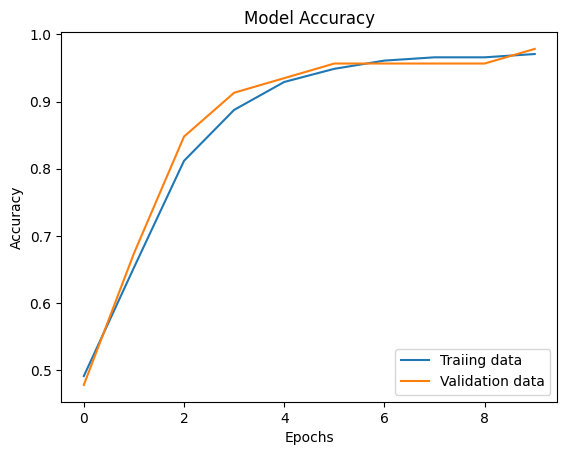

In [26]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend(['Traiing data', 'Validation data'], loc = 'lower right', )
plt.show()

## 📉 Loss Curve

Plot the Training Loss and Validation Loss over multiple epochs.

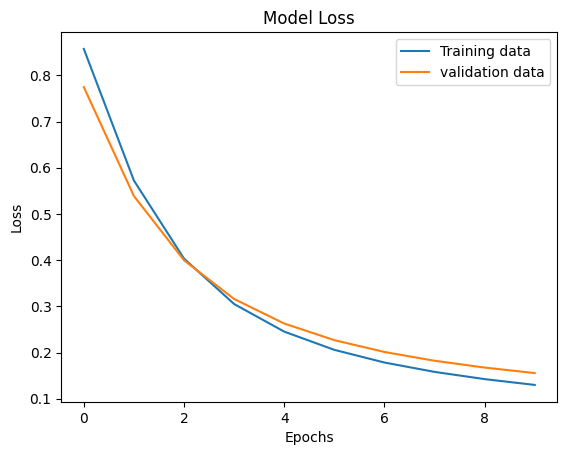

In [27]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend(['Training data', 'validation data'], loc = 'upper right')
plt.show()

# 🧪 Evaluating the Model

Evaluate the trained model on the unseen test dataset.

In [28]:
loss, accuracy = model.evaluate(X_test_Std, Y_test)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9649 - loss: 0.1381
Test Accuracy: 0.9649
Test Loss: 0.1381


In [29]:
print(X_test_Std.shape)
print(X_test_Std[0])

(114, 30)
[-0.04462793 -1.41612656 -0.05903514 -0.16234067  2.0202457  -0.11323672
  0.18500609  0.47102419  0.63336386  0.26335737  0.53209124  2.62763999
  0.62351167  0.11405261  1.01246781  0.41126289  0.63848593  2.88971815
 -0.41675911  0.74270853 -0.32983699 -1.67435595 -0.36854552 -0.38767294
  0.32655007 -0.74858917 -0.54689089 -0.18278004 -1.23064515 -0.6268286 ]


# 🔮 Making Predictions

Predict the class probabilities for the test dataset.

In [30]:
Y_pred = model.predict(X_test_Std)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


In [31]:
print(Y_pred.shape)
print(Y_pred[0])

(114, 2)
[0.21151848 0.78848153]


In [32]:
print(X_test_Std)

[[-0.04462793 -1.41612656 -0.05903514 ... -0.18278004 -1.23064515
  -0.6268286 ]
 [ 0.24583601 -0.06219797  0.21802678 ...  0.54129749  0.11047691
   0.0483572 ]
 [-1.26115925 -0.29051645 -1.26499659 ... -1.35138617  0.269338
  -0.28231213]
 ...
 [ 0.72709489  0.45836817  0.75277276 ...  1.46701686  1.19909344
   0.65319961]
 [ 0.25437907  1.33054477  0.15659489 ... -1.29043534 -2.22561725
  -1.59557344]
 [ 0.84100232 -0.06676434  0.8929529  ...  2.15137705  0.35629355
   0.37459546]]


In [33]:
print(Y_pred)

[[2.1151848e-01 7.8848153e-01]
 [2.9579338e-01 7.0420665e-01]
 [9.3905460e-03 9.9060953e-01]
 [9.9999964e-01 3.1702194e-07]
 [3.6077511e-01 6.3922489e-01]
 [9.9996495e-01 3.5096011e-05]
 [1.0746139e-01 8.9253861e-01]
 [1.9788042e-02 9.8021197e-01]
 [6.6797584e-02 9.3320245e-01]
 [6.3395642e-02 9.3660432e-01]
 [4.1489425e-01 5.8510572e-01]
 [5.1029116e-02 9.4897085e-01]
 [6.1920177e-02 9.3807977e-01]
 [1.9856550e-01 8.0143452e-01]
 [1.9825816e-02 9.8017418e-01]
 [9.5708042e-01 4.2919576e-02]
 [1.6175812e-02 9.8382413e-01]
 [3.4905791e-02 9.6509415e-01]
 [6.7188688e-02 9.3281132e-01]
 [9.9962461e-01 3.7533083e-04]
 [1.0732251e-03 9.9892670e-01]
 [1.5600151e-02 9.8439991e-01]
 [2.9113406e-02 9.7088659e-01]
 [3.0639295e-02 9.6936065e-01]
 [1.8908615e-01 8.1091386e-01]
 [9.9625802e-01 3.7420187e-03]
 [6.4033046e-02 9.3596697e-01]
 [2.6601979e-01 7.3398018e-01]
 [9.5715404e-01 4.2845991e-02]
 [9.9000078e-01 9.9992109e-03]
 [1.6137142e-01 8.3862859e-01]
 [8.4514342e-02 9.1548568e-01]
 [1.1441

model.predict() gives the prediction probability of each class for that data point

## 🎯 Converting Prediction Probabilities into Class Labels

Convert the predicted probabilities into final class labels using NumPy's argmax() function.

In [34]:
# Converting the prediction probability to class labels

Y_pred_labels = [np.argmax(i) for i in Y_pred]
print(Y_pred_labels)

[np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1)

# 🩺 Building the Predictive System

Create a predictive system that classifies whether a tumor is **Benign** or **Malignant** based on new input data.

## 📌 Prediction Result

Display the final prediction in a human-readable format.

- **Malignant Tumor**
- **Benign Tumor**

# The predictive system performs the following steps:

1. Accepts new patient data.
2. Converts it into a NumPy array.
3. Reshapes the data.
4. Applies the same StandardScaler used during training.
5. Predicts the probability for each class.
 6. Displays whether the tumor is Benign or Malignant.

In [35]:
input_data = (11.76,21.6,74.72,427.9,0.08637,0.04966,0.01657,0.01115,0.1495,0.05888,0.4062,1.21,2.635,28.47,0.005857,0.009758,0.01168,0.007445,0.02406,0.001769,12.98,25.72,82.98,516.5,0.1085,0.08615,0.05523,0.03715,0.2433,0.06563)

# Change the input_data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)


# Reshape the numpy array as we are predicting for one data point
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

# Standadizing the input data
input_data_std = scaler.transform(input_data_reshaped)

prediction = model.predict(input_data_std)
print(prediction)

prediction_label = [np.argmax(prediction)]
print(prediction_label)

if(prediction_label[0] == 0):
  print('The tumor is Malignant')

else:
  print('The tumor is Benign')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
[[0.0080386 0.9919614]]
[np.int64(1)]
The tumor is Benign


# 🎉 Conclusion

In this project, we successfully built an **Artificial Neural Network (ANN)** using **TensorFlow/Keras** to classify breast tumors as **Benign** or **Malignant** based on the Breast Cancer Wisconsin dataset.

The project demonstrates the complete **Deep Learning workflow**, including:

* 📥 Data Collection and Loading
* 🔍 Data Exploration and Analysis
* 🧹 Data Preprocessing
* ⚙️ Feature Standardization
* 🧠 Building an Artificial Neural Network (ANN)
* 🚀 Model Training
* 📊 Model Performance Visualization
* 🧪 Model Evaluation
* 🔮 Making Predictions
* 🩺 Building a Predictive System

This project provides a strong foundation for understanding how **Deep Learning models** can be applied to real-world healthcare problems, enabling accurate binary classification and serving as a stepping stone toward more advanced neural network architectures such as **Convolutional Neural Networks (CNNs)** and other deep learning models.
